# Day 35: Random Forest Basics
**Author:** Sahil-K-Y  
**Phase:** 3 - Tree Models & SVM  
**Date:** Day 035

---

## 1. Theoretical Foundations of Random Forests

Random Forest is a parallel ensemble learning method that constructs a forest of decision trees. It improves on Bagging by decorrelating the individual trees, significantly reducing model variance without a substantial increase in bias.

### A. Bootstrap Aggregating (Bagging)
Bagging reduces variance by averaging predictions from multiple trees trained on bootstrapped subsets of data. Bootstrapping samples $N$ instances randomly from the original dataset with replacement. 

### B. Random Feature Selection
While standard bagging decreases variance by averaging, if the features contain a few highly dominant predictors, the trees trained on different bootstrap samples will still look very similar (highly correlated). Random Forest solves this by only considering a random subset of features (typically $m = \sqrt{d}$) at each node split during tree construction. This decorrelates the trees.

### C. Mathematical Derivation of Variance Reduction
Let $X_1, X_2, \dots, X_B$ be $B$ decision trees, each having variance $\sigma^2$. If the trees are identically distributed but correlated with pairwise correlation $\rho > 0$, the variance of their average $\bar{X} = \frac{1}{B} \sum_{i=1}^B X_i$ is:
$$\text{Var}(\bar{X}) = \text{Var}\left(\frac{1}{B} \sum_{i=1}^B X_i\right) = \frac{1}{B^2} \text{Var}\left(\sum_{i=1}^B X_i\right)$$
$$\text{Var}(\bar{X}) = \frac{1}{B^2} \left[ \sum_{i=1}^B \text{Var}(X_i) + \sum_{i \ne j} \text{Cov}(X_i, X_j) \right]$$
Given $\text{Var}(X_i) = \sigma^2$ and $\text{Cov}(X_i, X_j) = \rho\sigma^2$ for $i \ne j$, and knowing there are $B(B-1)$ covariance terms:
$$\text{Var}(\bar{X}) = \frac{1}{B^2} \left[ B\sigma^2 + B(B-1)\rho\sigma^2 \right] = \frac{\sigma^2}{B} + \frac{B-1}{B}\rho\sigma^2 = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

As $B \to \infty$, the second term decays to 0. The variance is bounded below by $\rho\sigma^2$. Decreasing correlation $\rho$ via feature subspace splits is key to lowering this variance bound.

### D. Out-of-Bag (OOB) Estimation
Because bootstrap sampling is done with replacement, each bootstrap dataset leaves out about $36.8\%$ of the data. We can evaluate tree $b$ using its OOB samples. Averaging OOB estimates across all trees yields a reliable generalization score (OOB Score) equivalent to cross-validation.

## Exercise 1: Training a Random Forest and Visualizing OOB Convergence

We will use a synthetic dataset to train multiple Random Forest models and track their Out-of-Bag (OOB) and Test accuracy curves.

### Step 1.1: Loading and Preprocessing a Synthetic Dataset

In [66]:
import numpy as np
from sklearn.datasets import make_circles

# Generate classification dataset and print dataset shape
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.4, random_state=42)

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [68]:
df=pd.DataFrame(X)

In [69]:
df['Target']=y

<Axes: xlabel='0', ylabel='1'>

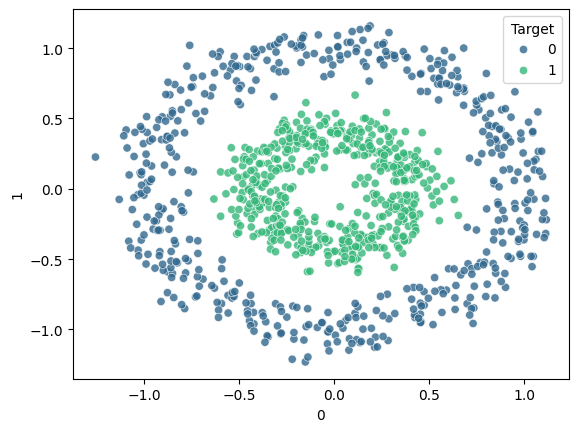

In [70]:
sns.scatterplot(data=df, x=0, y=1, hue='Target', palette='viridis', alpha=0.8)

### Step 1.2: Train-Test Split

In [71]:
from sklearn.model_selection import train_test_split

# Perform train-test split (80-20)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Step 1.3: Simulating Bootstrap and Feature Subspace Sampling from Scratch

In [72]:
# Write a function to simulate row bootstrap and column subspace selection using numpy
# Step 1.3: Simulating Bootstrap and Feature Subspace Sampling from Scratch
def simulate_rf_sampling(X, y, max_features='sqrt'):
    n_samples, n_features = X.shape
    
    # 1. Row sampling with replacement (Bootstrap)
    # Harek tree ke liye n_samples jitna hi data choose karenge, par replacement=True ke sath.
    # Iska matlab kuch rows repeat hongi aur lagbhag 36.8% rows chhoot jayengi (OOB samples).
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    X_boot, y_boot = X[boot_indices], y[boot_indices]
    
    # 2. Column sampling (Subspace Selection)
    # Agar max_features 'sqrt' hai, toh total features ka square root lenge (jaise 12 features ka sqrt ≈ 3)
    if max_features == 'sqrt':
        n_sub = int(np.sqrt(n_features))
    else:
        n_sub = n_features
        
    # replace=False taaki ek hi column do baar na select ho jaye
    selected_features = np.random.choice(n_features, size=n_sub, replace=False)
    
    return X_boot[:, selected_features], y_boot, selected_features

# Apne training data par ise test karte hain
X_sample, y_sample, feats = simulate_rf_sampling(X_train, y_train)
print(f"Selected feature subset indices (Kaunse columns chune gaye): {feats}")
print(f"Sample bootstrapped shape (Naya Data Shape): {X_sample.shape}")

Selected feature subset indices (Kaunse columns chune gaye): [0]
Sample bootstrapped shape (Naya Data Shape): (800, 1)


### Step 1.4: Evaluating Baseline Decision Tree

In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Ek simple Decision Tree model banayenge (bina kisi Random Forest ke)
base_tree = DecisionTreeClassifier(random_state=42)

# 2. Model ko apne Training Data par train karenge
base_tree.fit(X_train, y_train)

# 3. Check karenge ki model ne Train data par kaisa perform kiya
train_acc = accuracy_score(y_train, base_tree.predict(X_train))

# 4. Check karenge ki model ne Test data (naye data) par kaisa perform kiya
test_acc = accuracy_score(y_test, base_tree.predict(X_test))

# 5. Dono accuracy ko print karenge
print(f"Baseline Decision Tree -> Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")

Baseline Decision Tree -> Train Accuracy: 1.0000 | Test Accuracy: 0.9650


### Step 1.5: Tracking OOB Accuracy and Test Accuracy Convergence

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 10 se lekar 300 trees tak har 10 tree ke gap par check karenge
estimators_range = range(10, 301, 10)
oob_scores = []
test_scores = []

for n in estimators_range:
    # oob_score=True likhna zaroori hai tabhi chhoote hue 36.8% data par test hoga
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    # Scores ko list mein save kar rahe hain
    oob_scores.append(rf.oob_score_)
    test_scores.append(accuracy_score(y_test, rf.predict(X_test)))

print("Tracking Complete! Ab agle cell mein graph plot kar sakte hain.")

Tracking Complete! Ab agle cell mein graph plot kar sakte hain.


### Step 1.6: Plotting the Convergence Curves

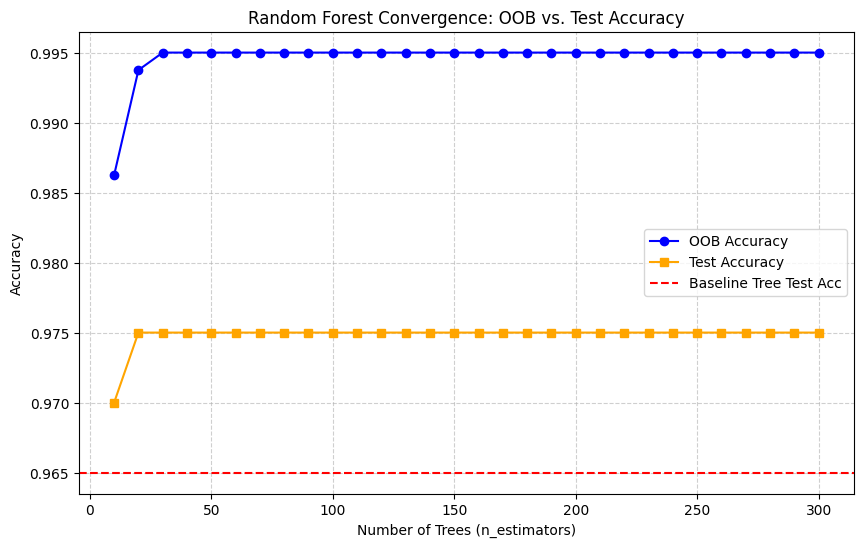

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# OOB aur Test accuracy ki curves plot kar rahe hain
plt.plot(estimators_range, oob_scores, label='OOB Accuracy', color='blue', marker='o')
plt.plot(estimators_range, test_scores, label='Test Accuracy', color='orange', marker='s')

# Baseline Decision Tree ka benchmark line (taaki comparison ho sake)
plt.axhline(y=test_acc, color='red', linestyle='--', label='Baseline Tree Test Acc')

# Graph ki styling
plt.title('Random Forest Convergence: OOB vs. Test Accuracy')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Step 1.7: Final Model Evaluation

In [76]:
from sklearn.metrics import precision_score, recall_score, f1_score

# 300 trees waala final model banayenge
final_rf = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=42, n_jobs=-1)
final_rf.fit(X_train, y_train)

# Test data par predictions nikaalenge
final_preds = final_rf.predict(X_test)

# Report Card Print karenge
print(f"--- Final Random Forest (300 Trees) Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, final_preds):.4f}")
print(f"OOB Score: {final_rf.oob_score_:.4f}")
print(f"Precision: {precision_score(y_test, final_preds):.4f}")
print(f"Recall:    {recall_score(y_test, final_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test, final_preds):.4f}")

--- Final Random Forest (300 Trees) Metrics ---
Accuracy:  0.9750
OOB Score: 0.9950
Precision: 1.0000
Recall:    0.9500
F1 Score:  0.9744
